In [1]:
# ==========================================
# Section 1 - Load Dataset
# COM763 Advanced Machine Learning
# ==========================================

# Import required library
import pandas as pd

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Dataset path
file_path = "/content/drive/MyDrive/Colab Notebooks/COM763-AI-Retail-Inventory-Forecasting/retail_store_inventory.csv"

# Load dataset
df = pd.read_csv(file_path)

# Display first 5 rows
display(df.head())

# Display dataset shape
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumns:")
print(df.columns.tolist())

# Display dataset information
print("\nDataset Information:")
df.info()

Mounted at /content/drive


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


Dataset Shape: (73100, 15)

Columns:
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount     

# Section 2 – Clean Data

In [3]:
# ==========================================
# Section 2 - Clean Data
# ==========================================

# 1. Check for missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

# 2. Check for duplicate records in the dataset
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate records: {duplicate_count}")

# 3. Remove duplicate records if any exist
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicates found to remove.")

# 4. Handle missing values
# Identify numerical and categorical columns
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill missing numerical values with the median
for col in numeric_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with the mode
for col in categorical_cols:
    if df[col].isnull().any():
        # .mode() returns a Series, so we take the first element [0]
        df[col] = df[col].fillna(df[col].mode()[0])

# 5. Verify that missing values have been handled
print("\nMissing values after cleaning:")
print(df.isnull().sum())

# 6. Display the dataset information
print("\nUpdated Dataset Information:")
df.info()

# 7. Display the cleaned dataset shape
print(f"\nCleaned Dataset Shape: {df.shape}")

Missing values per column:
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

Number of duplicate records: 0
No duplicates found to remove.

Missing values after cleaning:
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

Updated Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 col

# Section 3 – EDA (Graphs)

In [4]:
# ==========================================
# Section 3 - EDA
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Display summary statistics for numerical columns
# This gives us a quick overview of mean, standard deviation, and quartiles.
print("Summary Statistics:")
print("Dataset Shape:", df.shape)

print("\nColumn Names")
display(df.columns)
display(df.describe())

Summary Statistics:
Dataset Shape: (73100, 15)

Column Names


Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality'],
      dtype='object')

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


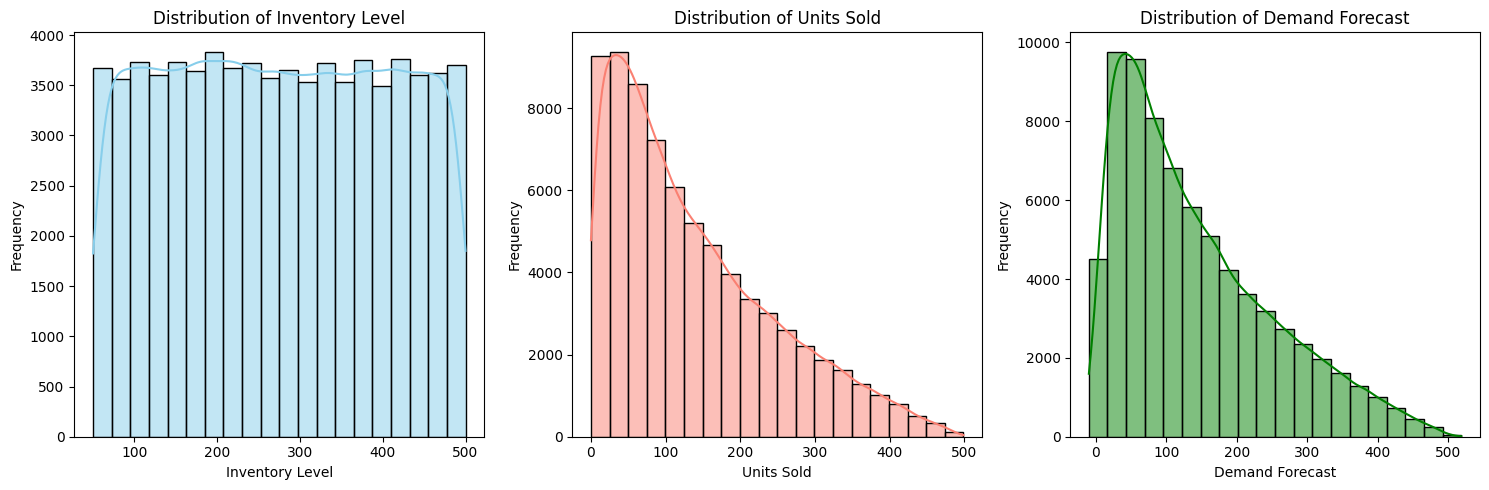

In [5]:
# 2. Plot Histograms for key numerical variables
# Histograms show the frequency distribution of data.
plt.figure(figsize=(15, 5))

# Histogram for Inventory Level
plt.subplot(1, 3, 1)
sns.histplot(df['Inventory Level'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Inventory Level')
plt.xlabel('Inventory Level')
plt.ylabel('Frequency')

# Histogram for Units Sold
plt.subplot(1, 3, 2)
sns.histplot(df['Units Sold'], bins=20, kde=True, color='salmon')
plt.title('Distribution of Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')

# Histogram for Demand Forecast
plt.subplot(1, 3, 3)
sns.histplot(df['Demand Forecast'], bins=20, kde=True, color='green')
plt.title('Distribution of Demand Forecast')
plt.xlabel('Demand Forecast')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Explanation: These histograms show how data points are spread.
# A peak indicates the most common value range.

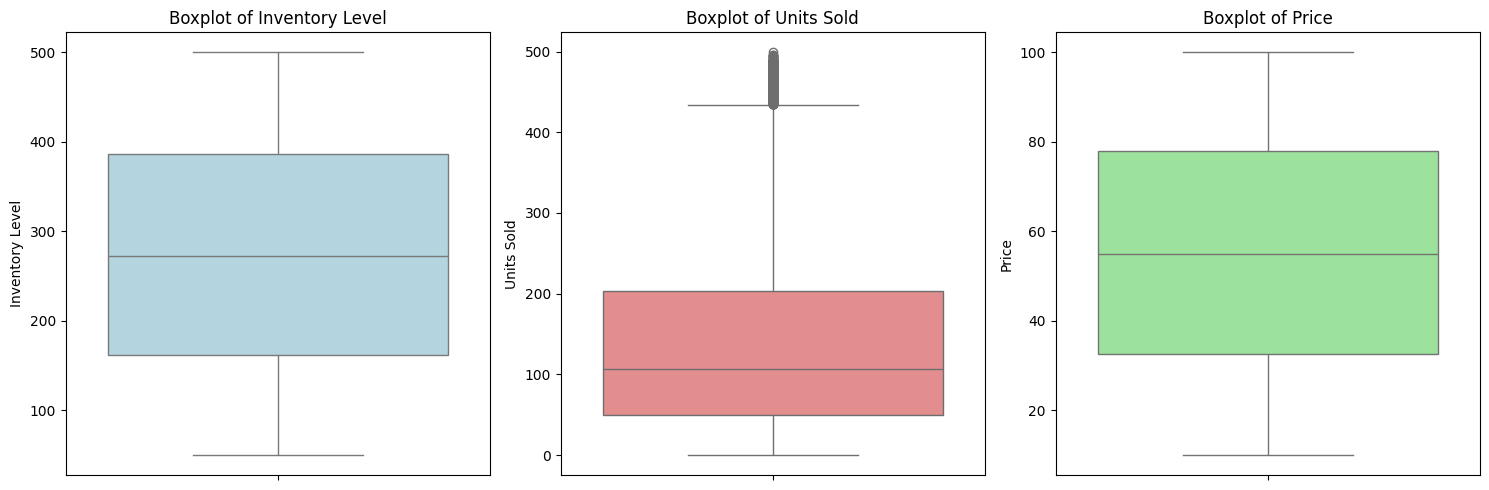

In [6]:
# 3. Plot Boxplots to identify outliers and quartiles
plt.figure(figsize=(15, 5))

# Boxplot for Inventory Level
plt.subplot(1, 3, 1)
sns.boxplot(y=df['Inventory Level'], color='lightblue')
plt.title('Boxplot of Inventory Level')
plt.ylabel('Inventory Level')

# Boxplot for Units Sold
plt.subplot(1, 3, 2)
sns.boxplot(y=df['Units Sold'], color='lightcoral')
plt.title('Boxplot of Units Sold')
plt.ylabel('Units Sold')

# Boxplot for Price
plt.subplot(1, 3, 3)
sns.boxplot(y=df['Price'], color='lightgreen')
plt.title('Boxplot of Price')
plt.ylabel('Price')

plt.tight_layout()
plt.show()

# Explanation: Boxplots show the median and identify potential outliers (dots outside the whiskers).

/tmp/ipykernel_818/3933301048.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Weather Condition', data=df, palette='magma')
/tmp/ipykernel_818/3933301048.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Seasonality', data=df, palette='cubehelix')


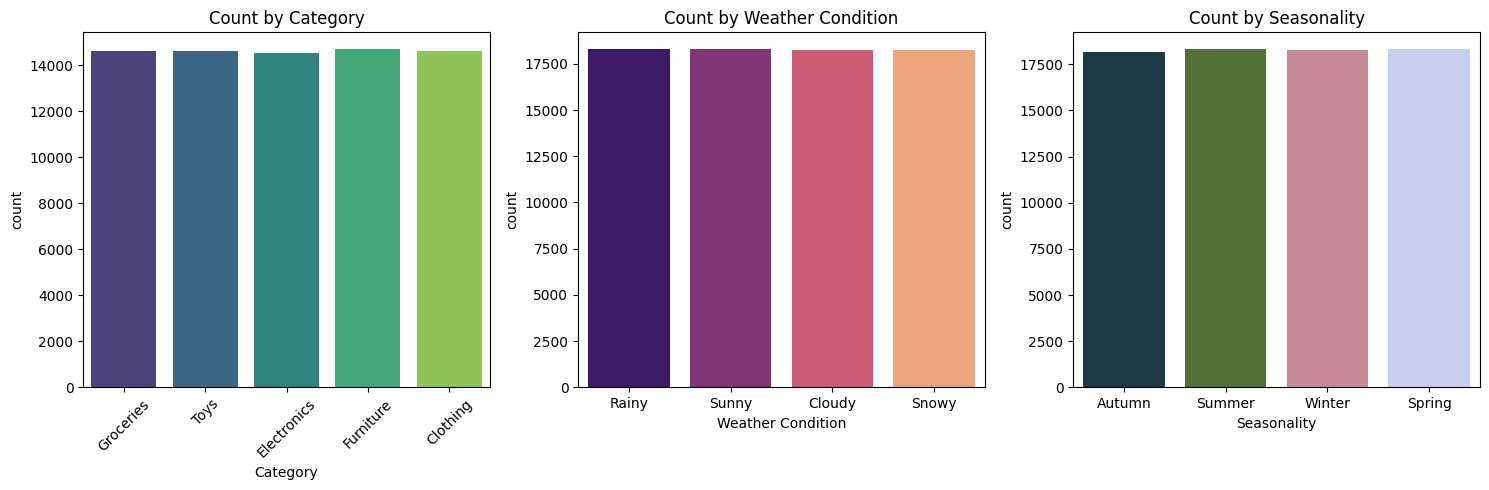

In [7]:
# 4. Plot Count Charts for categorical variables
# Count charts show the number of occurrences for each category.
plt.figure(figsize=(15, 5))

# Count Chart for Category
plt.subplot(1, 3, 1)
sns.countplot(
    x='Category',
    data=df,
    hue='Category',
    legend=False,
    palette='viridis'
)
plt.title('Count by Category')
plt.xticks(rotation=45)

# Count Chart for Weather Condition
plt.subplot(1, 3, 2)
sns.countplot(x='Weather Condition', data=df, palette='magma')
plt.title('Count by Weather Condition')

# Count Chart for Seasonality
plt.subplot(1, 3, 3)
sns.countplot(x='Seasonality', data=df, palette='cubehelix')
plt.title('Count by Seasonality')

plt.tight_layout()
plt.show()

# Explanation: These bars represent how many times each specific category appears in our dataset.

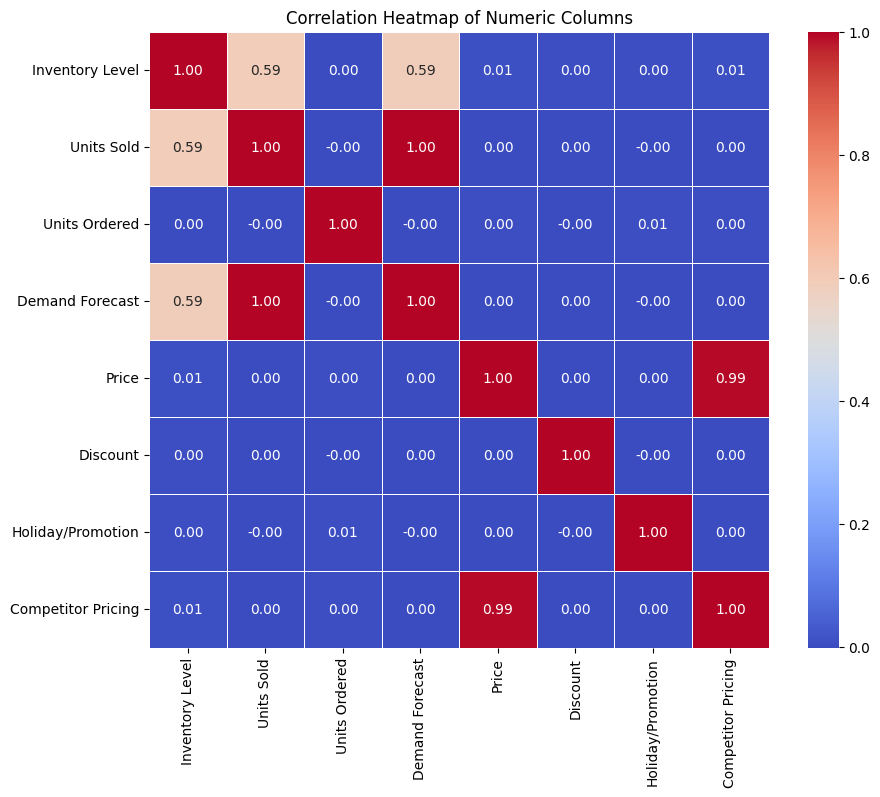

In [8]:
# 5. Plot a Correlation Heatmap
# A heatmap helps identify relationships between numerical variables.
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)
plt.title('Correlation Heatmap of Numeric Columns')
plt.show()

# Explanation: Values closer to 1 or -1 indicate a strong relationship between two variables.

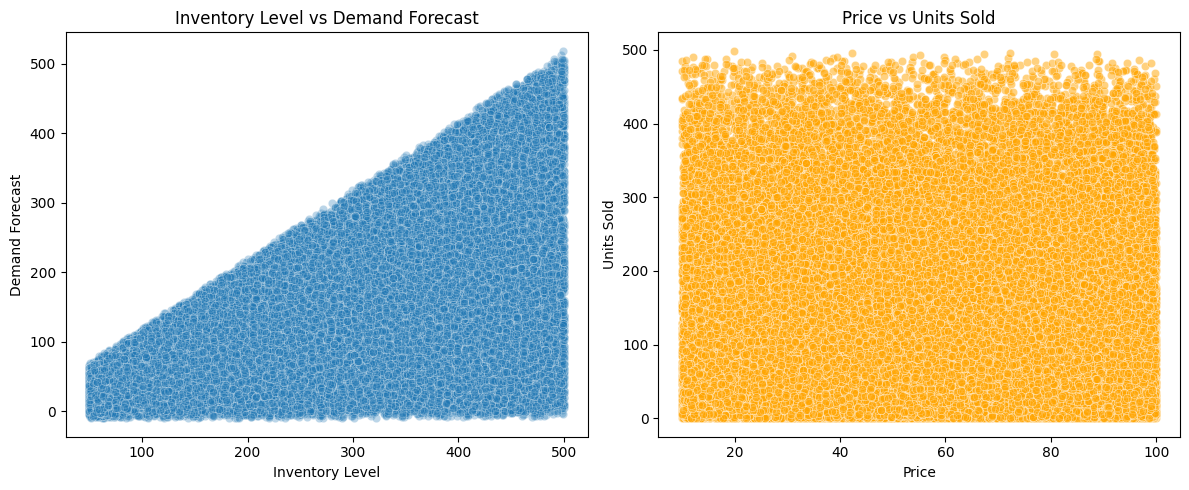

In [9]:
# 6. Plot Scatter Plots to see relationships
plt.figure(figsize=(12, 5))

# Scatter Plot: Inventory Level vs Demand Forecast
plt.subplot(1, 2, 1)
sns.scatterplot(x='Inventory Level', y='Demand Forecast', data=df, alpha=0.3)
plt.title('Inventory Level vs Demand Forecast')
plt.xlabel('Inventory Level')
plt.ylabel('Demand Forecast')

# Scatter Plot: Price vs Units Sold
plt.subplot(1, 2, 2)
sns.scatterplot(x='Price', y='Units Sold', data=df, alpha=0.5, color='orange')
plt.title('Price vs Units Sold')
plt.xlabel('Price')
plt.ylabel('Units Sold')

plt.tight_layout()
plt.show()

# Explanation: Scatter plots show if there is a trend (like a line) between two variables.

### Key Insights from EDA:
- **Distribution**: Most numerical variables show their central tendencies via histograms, helping identify typical sales and inventory ranges.
- **Outliers**: Boxplots highlight whether we have extreme values in Price or Units Sold that might affect model performance.
- **Categorical Balance**: The count plots reveal if certain Categories or Weather Conditions are more frequent than others.
- **Correlations**: The heatmap clarifies which features (like Demand Forecast) are most strongly related to our inventory levels.

In [18]:
# ==========================================
# Section 4 – Feature Engineering & Data Preparation
# ==========================================

import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Check if 'Date' exists before processing to avoid KeyError on multiple runs
if 'Date' in df.columns:
    # 1. Convert 'Date' column to datetime format
    df['Date'] = pd.to_datetime(df['Date'])

    # 2. Extract new features from the Date column
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df['DayOfWeek'] = df['Date'].dt.dayofweek

    # 3. Remove the original Date column
    df = df.drop(columns=['Date'])
    print("✅ Date features extracted and original column removed.")
else:
    print("☑️ 'Date' column already processed or not found.")

# 4. Automatically identify categorical (object) columns
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"Categorical columns identified for encoding: {categorical_cols.tolist()}")

# 5. Encode categorical columns using LabelEncoder
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# 6. Define Target variable (y) and Feature matrix (X)
# Target variable is 'Units Sold'
y = df['Units Sold']
# Feature matrix includes all columns except the target
X = df.drop(columns=['Units Sold'])

# 7. Verification and Display
print("\n--- Verification: Data Types ---")
print(X.dtypes)

print(f"\nFeature Matrix (X) Shape: {X.shape}")
print(f"Target Variable (y) Shape: {y.shape}")

print("\nSelected Feature Names:")
print(X.columns.tolist())

# Display the first 5 rows of the feature matrix
display(X.head())

☑️ 'Date' column already processed or not found.
Categorical columns identified for encoding: ['Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']

--- Verification: Data Types ---
Store ID                int64
Product ID              int64
Category                int64
Region                  int64
Inventory Level         int64
Units Ordered           int64
Demand Forecast       float64
Price                 float64
Discount                int64
Weather Condition       int64
Holiday/Promotion       int64
Competitor Pricing    float64
Seasonality             int64
dtype: object

Feature Matrix (X) Shape: (73100, 13)
Target Variable (y) Shape: (73100,)

Selected Feature Names:
['Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality']


,Store ID,Product ID,Category,Region,Inventory Level,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,0,0,3,1,231,55,135.47,33.50,20,1,0,29.69,0
1,0,1,4,2,204,66,144.04,63.01,20,3,0,66.16,0
2,0,2,4,3,102,51,74.02,27.99,10,3,1,31.32,2
3,0,3,4,1,469,164,62.18,32.72,10,0,1,34.74,0
4,0,4,1,0,166,135,9.26,73.64,0,3,0,68.95,2


```markdown
# ==========================================
# Section 5 – Train Machine Learning Models
# ==========================================
```

In [19]:
# 1. Import required libraries for modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# 2. Split the dataset into training and testing sets
# We use 80% for training and 20% for testing as requested.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Display the shapes of the split sets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# --- Training Models ---

# 4. Linear Regression
print("\nTraining Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

# 5. Decision Tree Regressor
print("Training Decision Tree...")
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

# 6. Random Forest Regressor
print("Training Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

# 7. Gradient Boosting Regressor
print("Training Gradient Boosting...")
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)
gb_predictions = gb_model.predict(X_test)

# 8. XGBoost Regressor
print("Training XGBoost...")
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)

print("\n✅ All models have been trained and predictions are stored in separate variables.")

X_train shape: (58480, 13)
X_test shape: (14620, 13)
y_train shape: (58480,)
y_test shape: (14620,)

Training Linear Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training XGBoost...

✅ All models have been trained and predictions are stored in separate variables.


```markdown
# ==========================================
# Section 6 – Model Evaluation & Comparison
# ==========================================
```

--- Model Performance Comparison ---


,Model,MAE,RMSE,R2 Score
0,Gradient Boosting,7.236629,8.462556,0.993951
1,Random Forest,7.244141,8.543896,0.993834
2,XGBoost,7.241214,8.549085,0.993827
3,Linear Regression,7.417796,8.600342,0.993753
4,Decision Tree,9.628659,11.931419,0.987976


/tmp/ipykernel_818/1278048402.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MAE', y='Model', data=results_df, ax=axes[0], palette='viridis')
/tmp/ipykernel_818/1278048402.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RMSE', y='Model', data=results_df, ax=axes[1], palette='magma')
/tmp/ipykernel_818/1278048402.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2 Score', y='Model', data=results_df, ax=axes[2], palette='coolwarm')


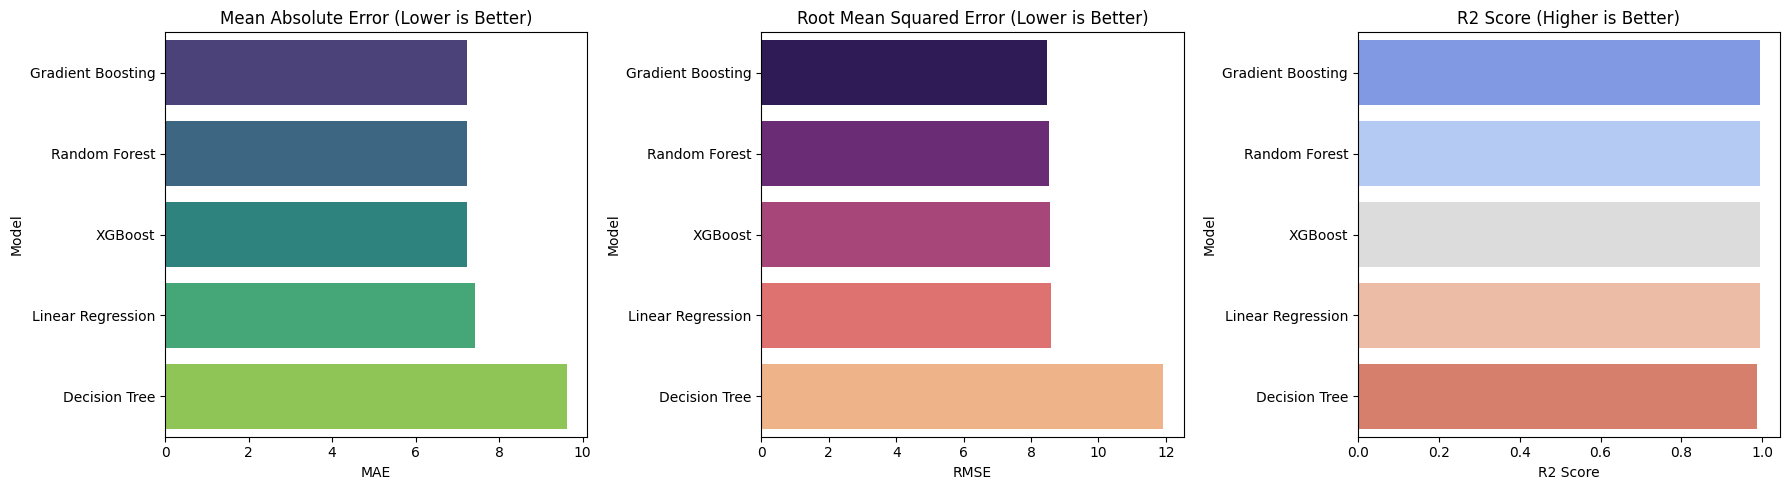


✅ Based on the R2 Score, the best performing model is: Gradient Boosting


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Define a function to calculate evaluation metrics
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2 Score': r2}

# 2. Collect results for all models
# Note: We ensure rf_model, gb_model, and xgb_model are evaluated assuming they finished training.
results_list = []
results_list.append(evaluate_model(y_test, lr_predictions, "Linear Regression"))
results_list.append(evaluate_model(y_test, dt_predictions, "Decision Tree"))
results_list.append(evaluate_model(y_test, rf_predictions, "Random Forest"))
results_list.append(evaluate_model(y_test, gb_predictions, "Gradient Boosting"))
results_list.append(evaluate_model(y_test, xgb_predictions, "XGBoost"))

# 3. Create a comparison DataFrame
results_df = pd.DataFrame(results_list)

# 4. Sort models by R2 Score (higher is better)
results_df = results_df.sort_values(by='R2 Score', ascending=False).reset_index(drop=True)

print("--- Model Performance Comparison ---")
display(results_df)

# 5. Visualize the comparisons
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE Comparison
sns.barplot(x='MAE', y='Model', data=results_df, ax=axes[0], palette='viridis')
axes[0].set_title('Mean Absolute Error (Lower is Better)')

# RMSE Comparison
sns.barplot(x='RMSE', y='Model', data=results_df, ax=axes[1], palette='magma')
axes[1].set_title('Root Mean Squared Error (Lower is Better)')

# R2 Score Comparison
sns.barplot(x='R2 Score', y='Model', data=results_df, ax=axes[2], palette='coolwarm')
axes[2].set_title('R2 Score (Higher is Better)')

plt.tight_layout()
plt.show()

# 6. Final Selection
best_model_name = results_df.iloc[0]['Model']
print(f"\n✅ Based on the R2 Score, the best performing model is: {best_model_name}")

# ==========================================
# Section 7 – Save Best Model
# ==========================================

```markdown
# ==========================================
# Section 7.1 – Save Streamlit-Compatible Bundle
# ==========================================
To make the Streamlit app work, we need to save the model along with the feature names and the label encoders used for categorical data.
```

In [23]:
import pickle

# 1. Re-collect LabelEncoders used in Section 4
# We will store them in a dictionary to save them
encoders = {}
categorical_cols = ['Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']

for col in categorical_cols:
    le = LabelEncoder()
    # We fit again on the original column to ensure the encoder is ready for the app
    # (Alternatively, if you saved the 'le' objects earlier, use those)
    le.fit(df_original[col] if 'df_original' in locals() else df[col])
    encoders[col] = le

# 2. Create the App Bundle
app_bundle = {
    'model': best_model_object,
    'encoders': encoders,
    'features': X.columns.tolist()
}

# 3. Save the Bundle
with open('inventory_app_model.pkl', 'wb') as f:
    pickle.dump(app_bundle, f)

print("✅ Streamlit bundle 'inventory_app_model.pkl' saved!")
print("This file contains: Model, LabelEncoders, and Feature Order.")

✅ Streamlit bundle 'inventory_app_model.pkl' saved!
This file contains: Model, LabelEncoders, and Feature Order.


```markdown
# ==========================================
# Section 10 – Download Project Files
# ==========================================
Run the cell below to download all necessary files for running your Streamlit app locally.
```

In [30]:
# 1. Create app.py
app_code = """
import streamlit as st
import pandas as pd
import pickle
import numpy as np

@st.cache_resource
def load_model():
    with open('inventory_app_model.pkl', 'rb') as f:
        return pickle.load(f)

data_bundle = load_model()
model = data_bundle['model']
encoders = data_bundle['encoders']
features = data_bundle['features']

st.title("📈 Retail Inventory Forecasting")

st.sidebar.header("Input Features")
store_id = st.sidebar.selectbox("Store ID", encoders['Store ID'].classes_)
product_id = st.sidebar.selectbox("Product ID", encoders['Product ID'].classes_)
category = st.sidebar.selectbox("Category", encoders['Category'].classes_)
region = st.sidebar.selectbox("Region", encoders['Region'].classes_)
inventory = st.sidebar.number_input("Inventory Level", value=100)
ordered = st.sidebar.number_input("Units Ordered", value=50)
forecast = st.sidebar.number_input("Demand Forecast", value=100.0)
price = st.sidebar.number_input("Price", value=50.0)
discount = st.sidebar.slider("Discount (%)", 0, 100, 10)
weather = st.sidebar.selectbox("Weather Condition", encoders['Weather Condition'].classes_)
holiday = st.sidebar.selectbox("Holiday/Promotion", [0, 1])
comp_price = st.sidebar.number_input("Competitor Pricing", value=45.0)
seasonality = st.sidebar.selectbox("Seasonality", encoders['Seasonality'].classes_)

input_data = pd.DataFrame([{
    'Store ID': encoders['Store ID'].transform([store_id])[0],
    'Product ID': encoders['Product ID'].transform([product_id])[0],
    'Category': encoders['Category'].transform([category])[0],
    'Region': encoders['Region'].transform([region])[0],
    'Inventory Level': inventory,
    'Units Ordered': ordered,
    'Demand Forecast': forecast,
    'Price': price,
    'Discount': discount,
    'Weather Condition': encoders['Weather Condition'].transform([weather])[0],
    'Holiday/Promotion': holiday,
    'Competitor Pricing': comp_price,
    'Seasonality': encoders['Seasonality'].transform([seasonality])[0]
}])

if st.button("Predict"):
    prediction = model.predict(input_data[features])
    st.success(f"Predicted Units Sold: {round(prediction[0], 2)}")
"""

with open('app.py', 'w') as f:
    f.write(app_code)

# 2. Create requirements.txt
with open('requirements.txt', 'w') as f:
    f.write("streamlit\npandas\nnumpy\nscikit-learn\nxgboost")

# 3. Trigger Download
from google.colab import files
for f in ['app.py', 'inventory_app_model.pkl', 'requirements.txt']:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>